In this notebook, Setup3 that uses velocity motion model is applied to KITTI dataset sequnece number 09 in 3 dimensional space to test the estimation accuracy. Besides the test, new setup, in which EKF and other filters are connected in series, is investigated and compare the estimation result between two setups:
- Setup3 in 3D space, where forward velocity is extracted from the OXTS INS sensor.
- New Setup in 3D space, where forward velocity is estimated using EKF and provided to the follwoing filter.

In addition to the estimation error, inference time for both setups are compared.

In [1]:
import os
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from utils import lla_to_enu, ecef_to_lla, get_rigid_transformation
from data_loader import DataLoader, CustomDataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from numpy.linalg import norm
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter,

    FilterWrapper
)

%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


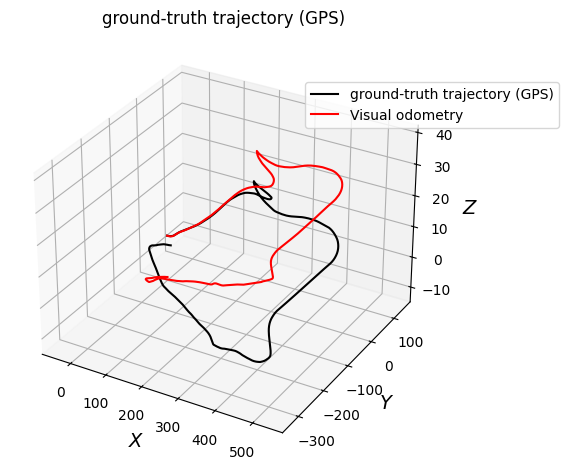

In [2]:
root_path = "../../../../"

kitti_root_dir = os.path.join(root_path, "data")
file_export_path = os.path.join(root_path, "exports/_sequences/09")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")

pose_dir = os.path.join(kitti_root_dir, "poses")
calib_dir = os.path.join(kitti_root_dir, "sequences", "09")

kitti_dataset = "0033"

data = DataLoader(
    sequence_nr=kitti_dataset, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    dimension=3
)

## Configs

In [3]:
setup = SetupEnum.SETUP_3
debug_mode = True
noise_type = NoiseTypeEnum.CURRENT
measurement_type = MeasurementDataEnum.ALL_DATA

interval = 1
dimension=3

# Setup3

## EKF

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 14324.53it/s]


----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.529 m
Root Mean Squared Error: 0.665 m
Maximum Error: 2.75 m
-----------------------------------------------



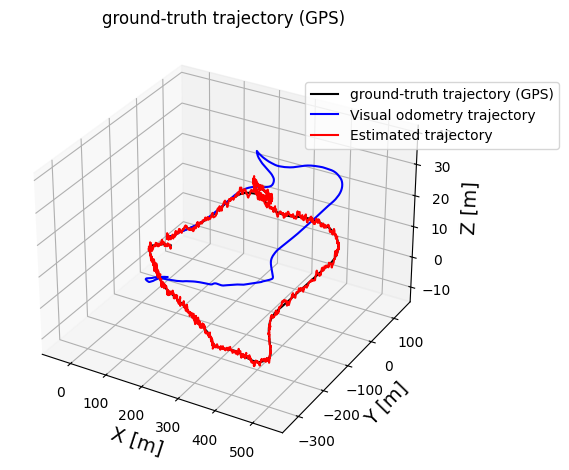

In [4]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=setup, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)

ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
error_ekf, inference_time_ekf = ekf.run_with_time(
    data=data, 
    debug_mode=debug_mode, 
    measurement_type=measurement_type
)
ekf.visualize_trajectory(
        data=data, 
        dimension=dimension, 
        interval=interval, 
        title="EKF Setup3 trajectories"
)

## UKF

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4321.99it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.972 m
Root Mean Squared Error: 1.381 m
Maximum Error: 5.376 m
-----------------------------------------------



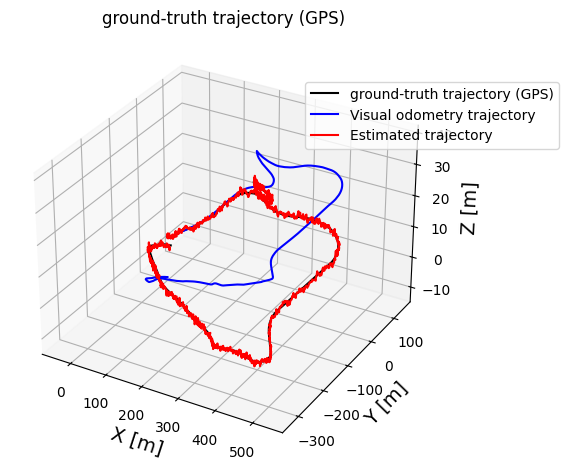

In [5]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=setup, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)

alpha = 0.1
beta = 2.
kappa = 0.


ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=setup
)
error_ukf, inference_time_ukf = ukf.run_with_time(
    data=data, 
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

ukf.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=interval, 
    title="UKF Setup3 trajectories"
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:20<00:00, 76.63it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.953 m
Root Mean Squared Error: 1.207 m
Maximum Error: 5.14 m
----------------------------------------------



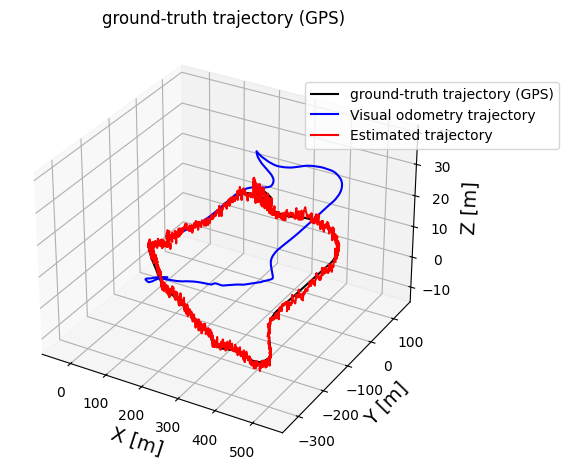

In [6]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=setup, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)

n_samples = 512
resampling_algorithm = ResamplingAlgorithms.RESIDUAL
importance_resampling = True

pf = ParticleFilter(
    N=n_samples, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=setup,
    resampling_algorithm=resampling_algorithm
)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())
error_pf, inference_time_pf = pf.run_with_time(
    data=data,
    debug_mode=debug_mode,
    measurement_type=measurement_type, 
    importance_resampling=importance_resampling
)

pf.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=interval, 
    title="PF Setup3 trajectories"
)

## EnKF

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1373.42it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.952 m
Root Mean Squared Error: 1.2 m
Maximum Error: 4.853 m
------------------------------------------------



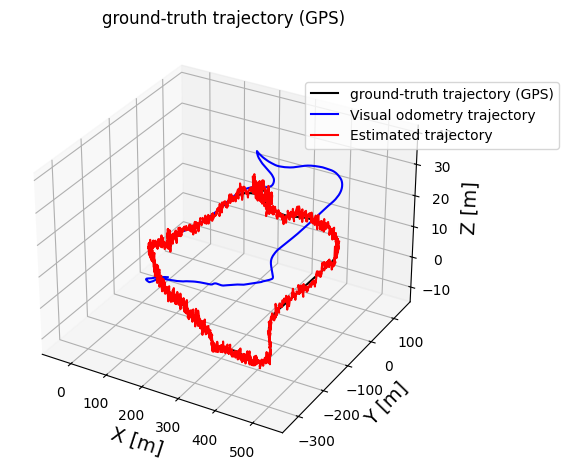

In [7]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=setup, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)

n_ensemble = 64

enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=setup
)
error_enkf, inference_time_enkf = enkf.run_with_time(
    data=data, 
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

enkf.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=interval, 
    title="EnKF Setup3 trajectories"
)

## CKF

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4626.07it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.972 m
Root Mean Squared Error: 1.38 m
Maximum Error: 5.376 m
-----------------------------------------------



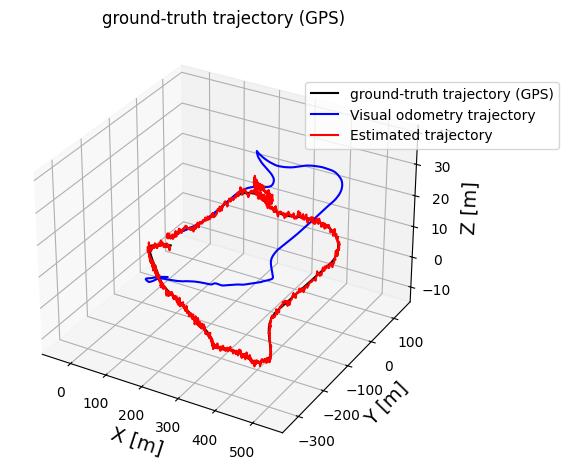

In [8]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=setup, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=setup,
)
error_ckf, inference_time_ckf = ckf.run_with_time(
    data=data, 
    debug_mode=debug_mode,
    measurement_type=measurement_type
)

ckf.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=interval, 
    title="CKF Setup3 trajectories"
)

# New setup

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


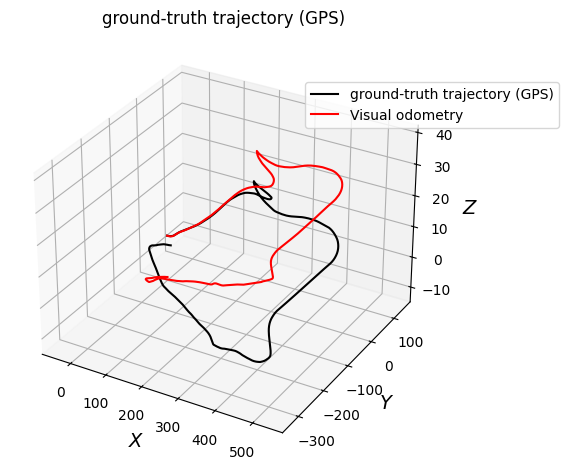

In [9]:
data = CustomDataLoader(
    sequence_nr=kitti_dataset, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=True,
    dimension=3
)

## EKF

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4133.19it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 7.099 m
Root Mean Squared Error: 10.821 m
Maximum Error: 32.696 m
-----------------------------------------------



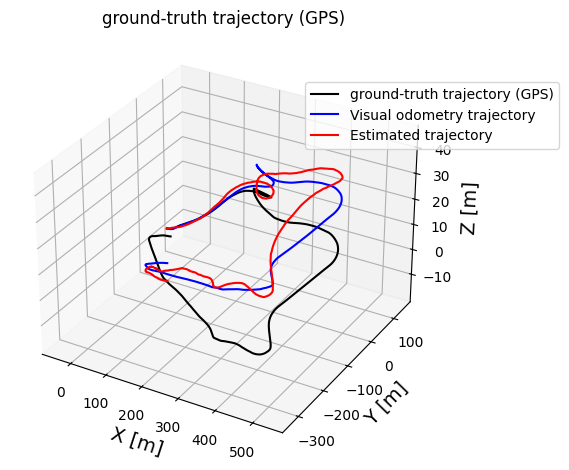

In [10]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_wrapper = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
    omit_gps=True,
)
error_wrapped_ekf, inference_time_wrapped_ekf = ekf_wrapper.run(
    data=data, 
    debug_mode=True, 
    show_graph=False,
    measurement_type=MeasurementDataEnum.DROPOUT
)
ekf_wrapper.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=5, 
    title="EKF Setup3 trajectories"
)

## UKF

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2367.03it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.977 m
Root Mean Squared Error: 1.386 m
Maximum Error: 5.836 m
-----------------------------------------------



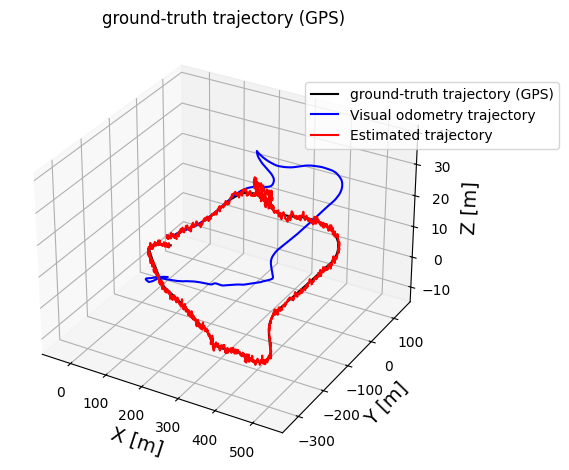

In [11]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=1.0, 
    beta=2.0, 
    kappa=0.0,
    setup=SetupEnum.SETUP_3
)
ukf_wrapper = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
    omit_gps=True,
)
error_wrapped_ukf, inference_time_wrapped_ukf = ukf_wrapper.run(
    data=data, 
    debug_mode=True, 
    show_graph=False,
    measurement_type=MeasurementDataEnum.DROPOUT
)

ukf_wrapper.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=5, 
    title="UKF Setup3 trajectories"
)

## PF

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:13<00:00, 122.00it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 86.683 m
Root Mean Squared Error: 165.318 m
Maximum Error: 607.567 m
----------------------------------------------



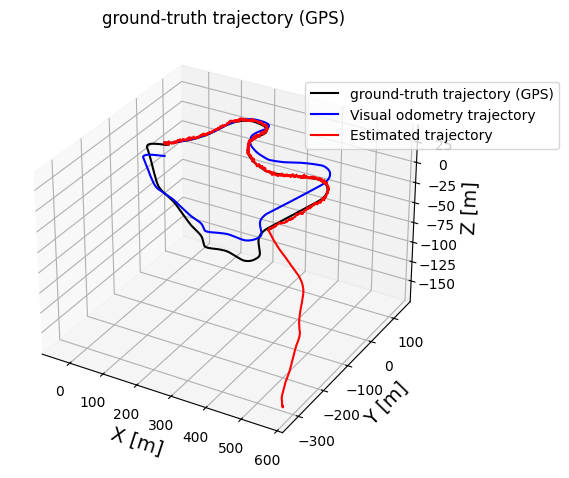

In [12]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF,
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=256, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())
particle_filter = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
    omit_gps=True
)
error_wrapped_pf, inference_time_wrapped_pf = particle_filter.run(
    data=data, 
    debug_mode=True, 
    show_graph=False,
    measurement_type=MeasurementDataEnum.DROPOUT
)
particle_filter.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=5, 
    title="PF Setup3 trajectories"
)

## EnKF

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1062.26it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.962 m
Root Mean Squared Error: 1.213 m
Maximum Error: 4.726 m
------------------------------------------------



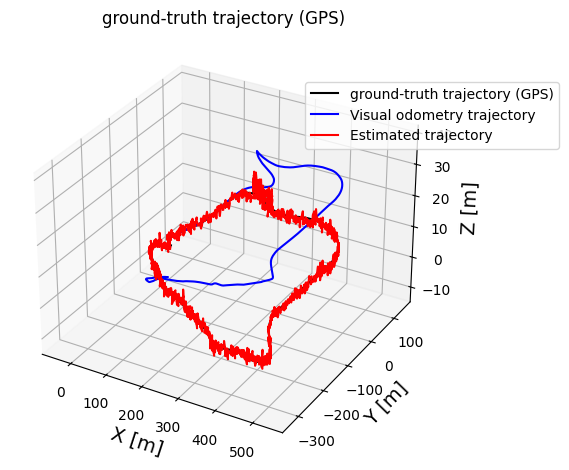

In [13]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_wrapper = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
    omit_gps=True
)
error_wrapped_enkf, inference_time_wrapped_enkf = enkf_wrapper.run(
    data=data, 
    debug_mode=True, 
    show_graph=False,
    measurement_type=MeasurementDataEnum.DROPOUT
)
enkf_wrapper.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=5, 
    title="EnKF Setup3 trajectories"
)

## CKF

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2237.00it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.976 m
Root Mean Squared Error: 1.385 m
Maximum Error: 5.833 m
-----------------------------------------------



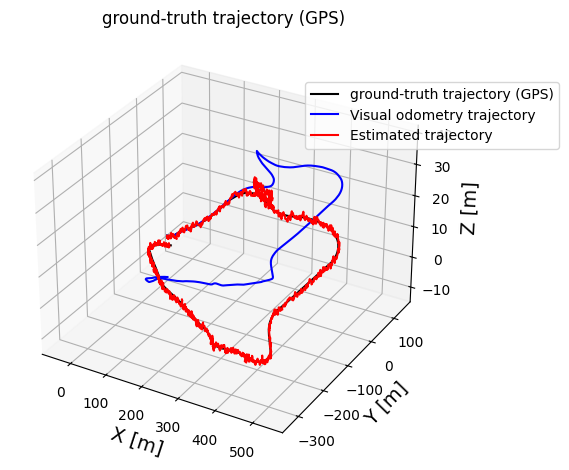

In [14]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF,
    noise_type=NoiseTypeEnum.CURRENT
)
_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ckf_wrapper = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
    omit_gps=True,
)
error_wrapped_ckf, inference_time_wrapped_ckf = ckf_wrapper.run(
    data=data, 
    debug_mode=True, 
    show_graph=False,
    measurement_type=MeasurementDataEnum.DROPOUT
)
ckf_wrapper.visualize_trajectory(
    data=data, 
    dimension=dimension, 
    interval=5, 
    title="CKF Setup3 trajectories"
)

In [15]:
error_current = [error_ekf, error_ukf, error_pf, error_enkf, error_ckf]
error_new = [error_wrapped_ekf, error_wrapped_ukf, error_wrapped_pf, error_wrapped_enkf, error_wrapped_ckf]
errors = []